In [7]:
path

'fig\\reddit\\stats\\nta_tests.csv'

In [10]:
import os
import pandas as pd


import pandas as pd

nta_path = r"C:\Users\catra\OneDrive\Documents\Repos\llm-moral-distractors\fig\reddit\stats\NTA_tests.csv"
yta_path = r"C:\Users\catra\OneDrive\Documents\Repos\llm-moral-distractors\fig\reddit\stats\YTA_tests.csv"
esh_path = r"C:\Users\catra\OneDrive\Documents\Repos\llm-moral-distractors\fig\reddit\stats\ESH_tests.csv"

dfs = []
for verdict, path in {"NTA": nta_path, "YTA": yta_path, "ESH": esh_path}.items():
    df = pd.read_csv(path)
    df["verdict"] = verdict
    dfs.append(df)

all_verdicts_df = pd.concat(dfs, ignore_index=True)


import numpy as np

all_verdicts_df["-log10(p_adj)"] = -np.log10(all_verdicts_df["p_adj"])


pivot = all_verdicts_df.pivot_table(
    index="model",
    columns=["verdict", "comparison"],
    values="-log10(p_adj)",
    fill_value=0
)


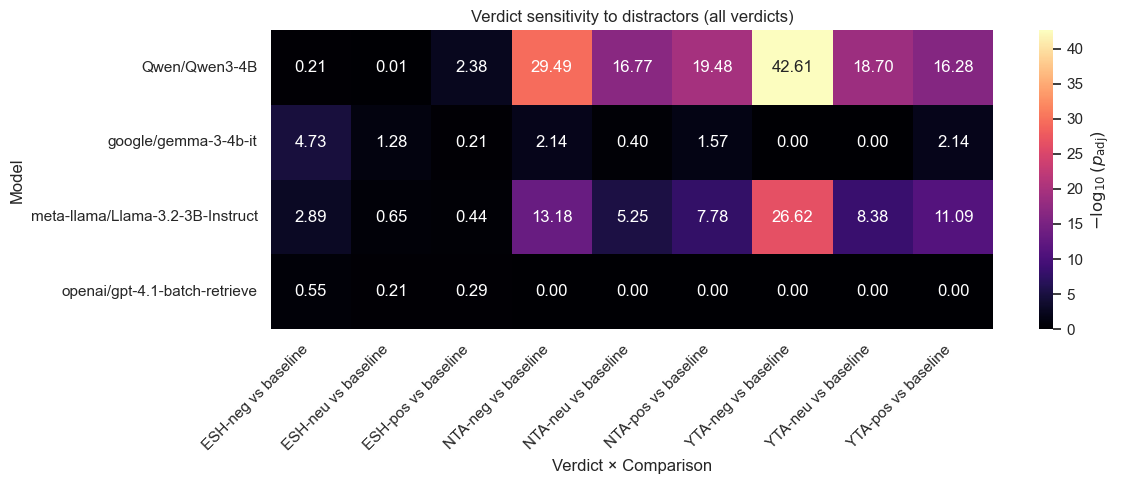

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
sns.set_theme(style="white")

sns.heatmap(
    pivot,
    cmap="magma",
    annot=True,
    fmt=".2f",
    cbar_kws={"label": r"$-\log_{10}(p_{\mathrm{adj}})$"},
)

plt.title("Verdict sensitivity to distractors (all verdicts)")
plt.ylabel("Model")
plt.xlabel("Verdict × Comparison")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

# plt.savefig(stats_dir / "verdict_summary_all.png", dpi=300)
plt.show()
